#### Interactive notebook to try tracking

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import trackpy as tp
from sklearn.linear_model import LinearRegression
import pickle

In [10]:
# Create the DataFrame (already done, saed as pickle)

# import pandas as pd
# import pickle

# video_array_resample = video_array[::4,:,:]
# x_positions = []
# y_positions = []
# frames = []
# for i in range(video_array_resample.shape[0]):
#     x, y = super_locs(video_array_resample[i,:,:],intensity_threshold=250,dist_threshold=50)
#     number_of_localizations = len(x)
#     print(f"Number of localizations for frame {i}: {number_of_localizations}")
#     x_positions.extend(x)
#     y_positions.extend(y)
#     frames.extend([i]*number_of_localizations)

# dicto = {'x':x_positions,
#          'y':y_positions,
#          'frame':frames}
    
# df = pd.DataFrame(dicto)

# # Save the DataFrame to a pickle file
# with open('dataframe.pkl', 'wb') as f:  # 'wb' = write binary
#     pickle.dump(df, f)

Frame 33: 16 trajectories present.


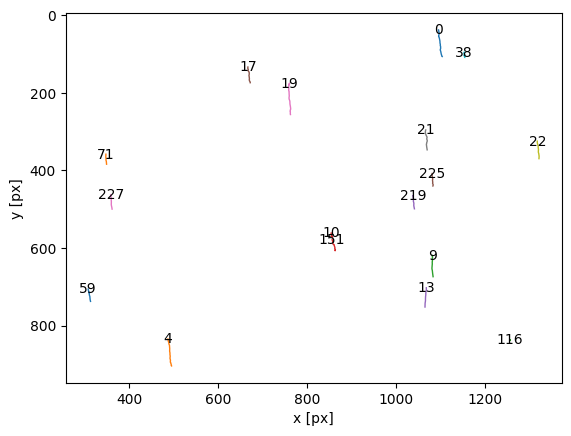

In [11]:
# Load the DataFrame from the pickle file
with open('dataframe.pkl', 'rb') as f:  # 'rb' = read binary
    df = pickle.load(f)

# Perform the tracking
tracked = tp.link(df, search_range=10)  # Adjust search_range

#remove track with less than 10 localizations
tracked = tp.filter_stubs(tracked, 10)

tp.plot_traj(tracked, label=True)
plt.show()

#### Example: substracting the linear term from the particule's motion

- $x(t) = x_0 + v_x \cdot t + x_{random}(t)$
- $y(t) = y_0 + v_y \cdot t + y_{random}(t)$


<function matplotlib.pyplot.show(close=None, block=None)>

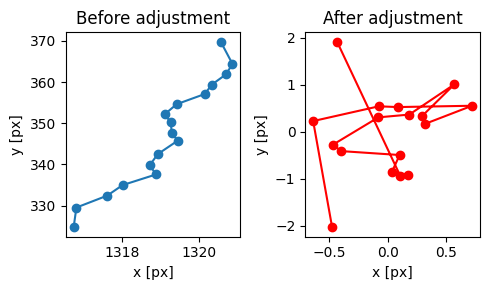

In [12]:
# Test for a single particle

particule = 22
x_before_adjust = np.array(tracked[tracked['particle'] == particule]['x'])
y_before_adjust = np.array(tracked[tracked['particle'] == particule]['y'])
t = np.array(tracked[tracked['particle'] == particule]['frame'])

reg_x = LinearRegression().fit(t.reshape(-1, 1), x_before_adjust)
reg_y = LinearRegression().fit(t.reshape(-1, 1), y_before_adjust)

x_adjusted = x_before_adjust - reg_x.predict(t.reshape(-1, 1))
y_ajusted = y_before_adjust - reg_y.predict(t.reshape(-1, 1))


plt.figure(figsize=(5,3), dpi=100)
plt.subplot(1, 2, 1)
plt.plot(x_before_adjust, y_before_adjust, 'o-')
plt.title('Before adjustment')
plt.xlabel('x [px]')
plt.ylabel('y [px]')

plt.subplot(1, 2, 2)
plt.plot(x_adjusted, y_ajusted, 'o-', color='r')
plt.title('After adjustment')
plt.xlabel('x [px]')
plt.ylabel('y [px]')
plt.tight_layout()
plt.show

In [13]:
# List all remaining particles
particle_list = tracked['particle'].unique()

print(particle_list)

[  0   4   9  10  13  17  19  21  22  38  59  71 116 151 219 225 227]


#### MSD calculation

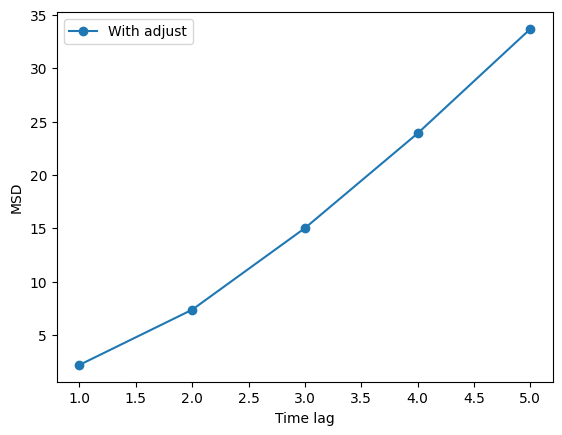

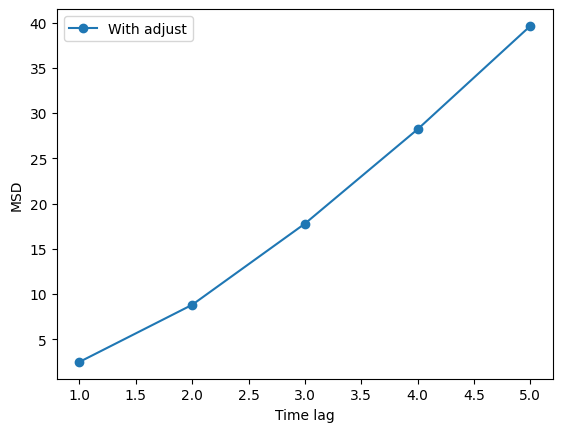

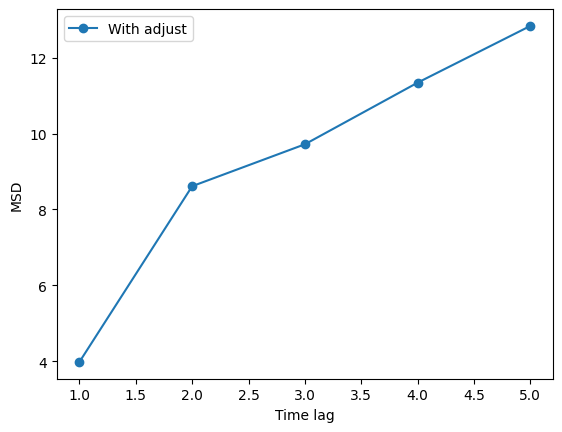

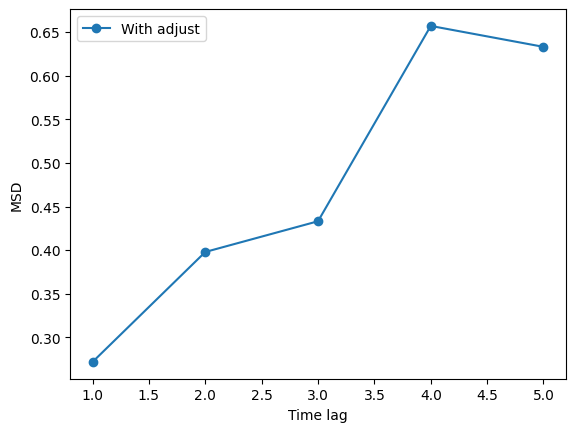

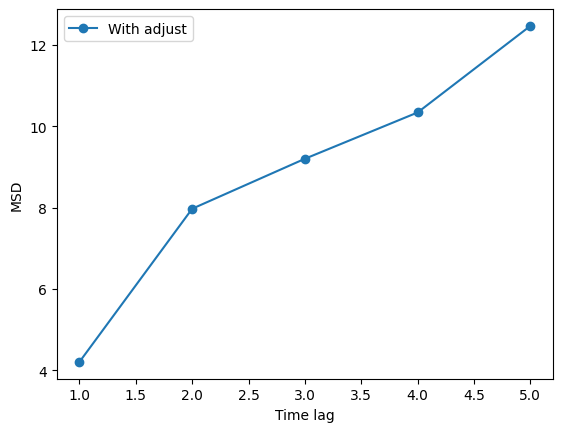

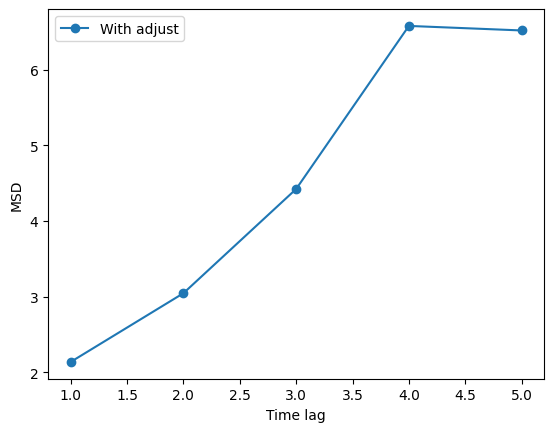

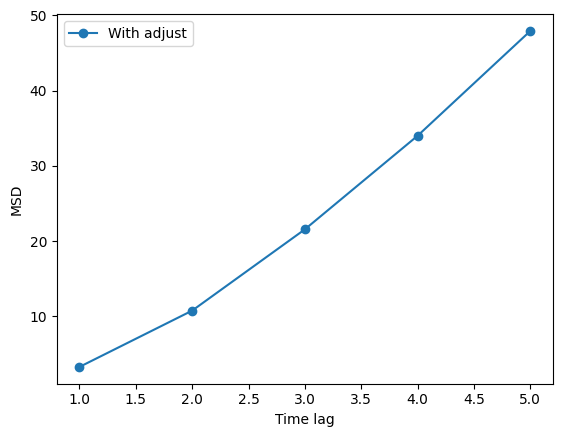

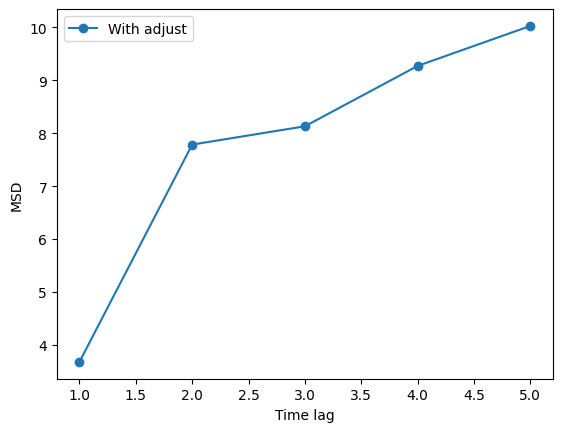

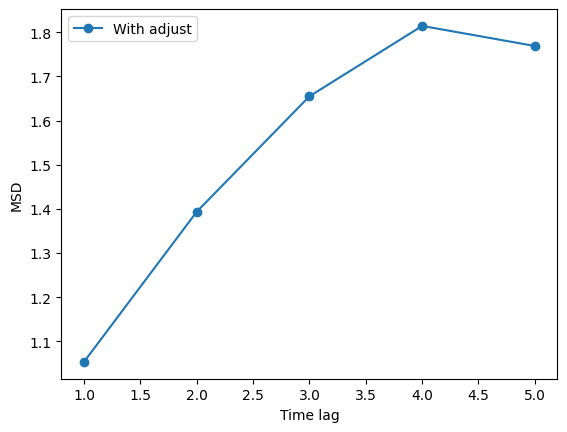

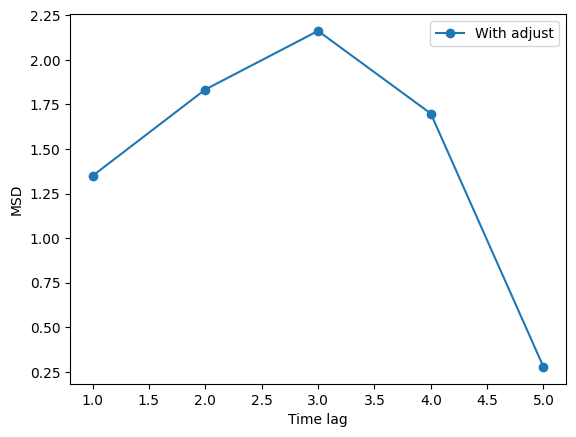

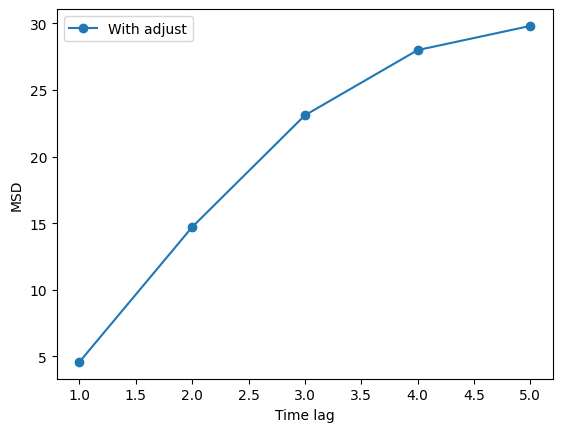

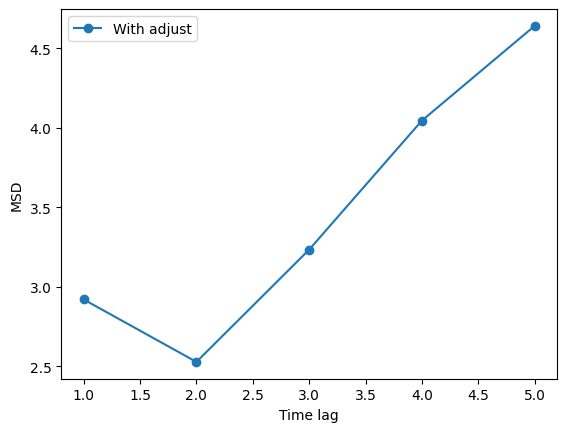

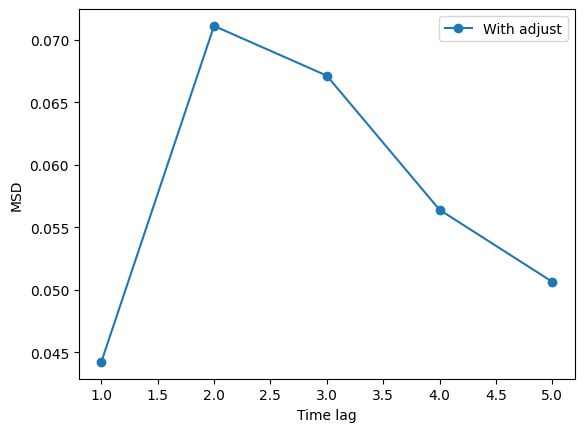

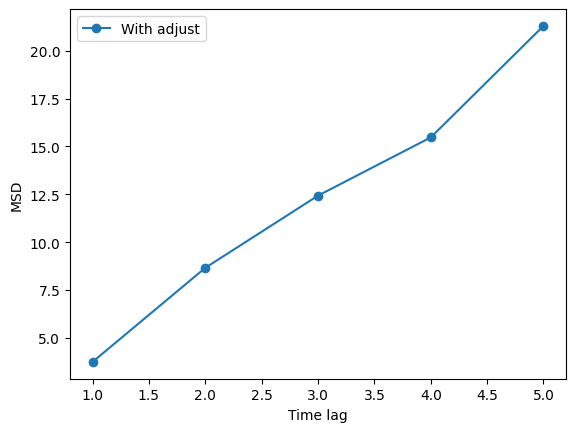

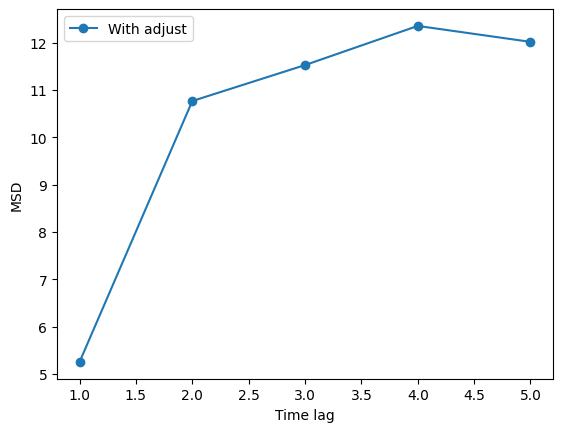

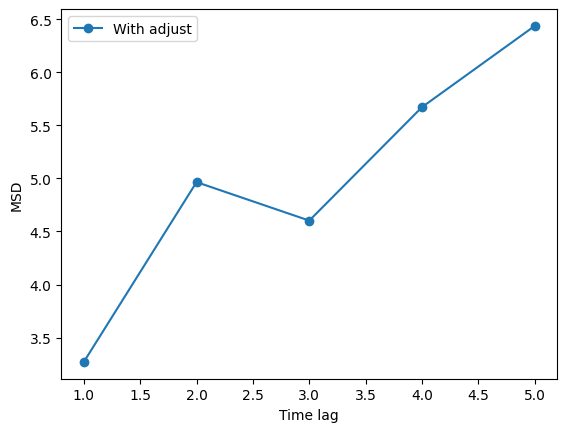

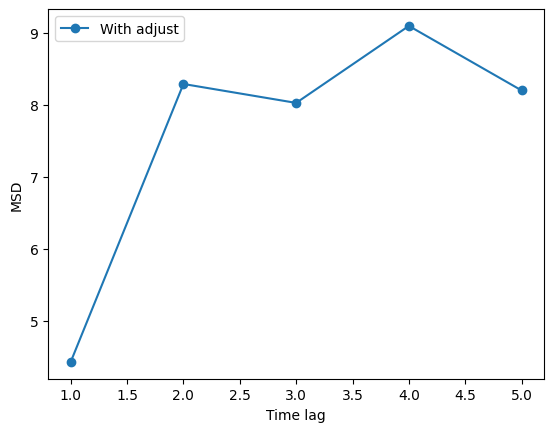

In [14]:
# List all remaining particles
particle_list = tracked['particle'].unique()

def adjust_trajectories(tracked, particle_list):
    for particle in particle_list:
        x_before_adjust = np.array(tracked[tracked['particle'] == particle]['x'])
        y_before_adjust = np.array(tracked[tracked['particle'] == particle]['y'])
        t = np.array(tracked[tracked['particle'] == particle]['frame'])

        reg_x = LinearRegression().fit(t.reshape(-1, 1), x_before_adjust)
        reg_y = LinearRegression().fit(t.reshape(-1, 1), y_before_adjust)

        x_adjusted = x_before_adjust - reg_x.predict(t.reshape(-1, 1))
        y_ajusted = y_before_adjust - reg_y.predict(t.reshape(-1, 1))

        tracked.loc[tracked['particle'] == particle, 'x'] = x_adjusted
        tracked.loc[tracked['particle'] == particle, 'y'] = y_ajusted
    return tracked

tracked_without_adjust = tracked.copy()
tracked_with_adjust = adjust_trajectories(tracked, particle_list)

particule = 10
# Get only the x positions of the particule 0

for particule in particle_list:
    x_positions = np.array(tracked_with_adjust[tracked_with_adjust['particle'] == particule]['x'])
    y_positions = np.array(tracked_with_adjust[tracked_with_adjust['particle'] == particule]['y'])
    t = np.array(tracked_with_adjust[tracked_with_adjust['particle'] == particule]['frame'])

    # Calculate the MSD for different time lags
    msd = []
    time_lags = np.arange(1, 6)

    for time_lag in time_lags:
        x_lag = x_positions[:-time_lag]
        y_lag = y_positions[:-time_lag]
        x_lead = x_positions[time_lag:]
        y_lead = y_positions[time_lag:]
        
        msd.append(np.sum(np.mean((x_lead - x_lag)**2) + np.mean((y_lead - y_lag)**2)))


    plt.plot(time_lags, msd, 'o-', label='With adjust')
    plt.xlabel('Time lag')
    plt.ylabel('MSD')
    plt.legend()
    plt.show()